# CSCE 40103 Module 3 - Assignment 2
## LAB 2: EMAIL Threat Detection

**Dataset used:** Enron Spam Dataset

Date - Jun 13 2026
Name - Bryant Baum


## Setup

In [465]:
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModel
# Optional for fine-tuning:
# from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC, SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

LOCAL_CSV = Path("Enron_Spam_Dataset.csv")

print("Setup complete. No package installation or internet access required.")

Setup complete. No package installation or internet access required.


## Part 1: Dataset Loading and Inspection

Load the dataset and inspect its structure before any modeling.

In [466]:
def load_spam_dataset(local_csv: Path = LOCAL_CSV) -> pd.DataFrame:
    # Load the phishing dataset without internet or package installation.
    if local_csv.exists():
        print(f"Loading local CSV file: {local_csv}")
        loaded_df = pd.read_csv(local_csv)
    else:
        print("Local CSV not found")

    return loaded_df


df = load_spam_dataset()
print("Dataset loaded successfully.")
df.head()

Loading local CSV file: Enron_Spam_Dataset.csv
Dataset loaded successfully.


,Message ID,Subject,Message,Spam/Ham,Date
0,0,christmas tree farm pictures,NaN,ham,1999-12-10
1,1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13
2,2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14
3,3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14
4,4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14


# Shape

In [467]:
print("Rows and columns:", df.shape)
print("Column names:", list(df.columns))
print("Data types:")
print(df.dtypes)

Rows and columns: (33716, 5)
Column names: ['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date']
Data types:
Message ID    int64
Subject         str
Message         str
Spam/Ham        str
Date            str
dtype: object


# Missing Values

In [468]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
Message ID      0
Subject       289
Message       371
Spam/Ham        0
Date            0
dtype: int64


# Duplicates

In [469]:
exact_dupes = df.duplicated().sum()
print("Exact duplicate rows (all columns):", exact_dupes) 

Exact duplicate rows (all columns): 0


# Class Counts/ Percentages

In [470]:
class_counts = df["Spam/Ham"].value_counts()
class_pct = df["Spam/Ham"].value_counts(normalize=True).mul(100)
print("Class counts:")
print(class_counts)
print()
print("Class percentages:")
print(class_pct)

Class counts:
Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

Class percentages:
Spam/Ham
spam    50.928343
ham     49.071657
Name: proportion, dtype: float64


## Part 2: Construct the Email Text Field

Create one model input column by combining Subject and Message. This combined text field should be
used for all text classification models

In [471]:
df["Subject"] = df["Subject"].fillna("")
df["Message"] = df["Message"].fillna("")
df["text"] = (df["Subject"] + " " + df["Message"]).str.strip()

df[["Subject", "Message", "text", "Spam/Ham"]].head()

,Subject,Message,text,Spam/Ham
0,christmas tree farm pictures,,christmas tree farm pictures,ham
1,"vastar resources , inc .","gary , production from the high island larger ...","vastar resources , inc . gary , production fro...",ham
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,calpine daily gas nomination - calpine daily g...,ham
3,re : issue,fyi - see note below - already done .\nstella\...,re : issue fyi - see note below - already done...,ham
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,meter 7268 nov allocation fyi .\n- - - - - - -...,ham


In [472]:
text_len = df["text"].str.len()
empty_count = (text_len == 0).sum()
near_empty_count = (text_len <= 2).sum()
print("Empty combined-text records:", empty_count)
print("Near-empty (<= 2 chars) records:", near_empty_count)
print("Rows before removing empty:", len(df))

Empty combined-text records: 51
Near-empty (<= 2 chars) records: 52
Rows before removing empty: 33716


In [473]:
before = len(df)
df_clean = df[df["text"].str.strip() != ""].copy()
print("Removed empty-text rows:", before - len(df_clean))
print("Rows after removing empty:", len(df_clean))

Removed empty-text rows: 51
Rows after removing empty: 33665


In [474]:
dup_text = df_clean["text"].duplicated().sum()
print("Duplicate combined-text records:", dup_text)

df_clean = df_clean.drop_duplicates(subset="text").copy()
print("Final row count after cleaning:", len(df_clean))
print()
print("Class distribution after cleaning:")
print(df_clean["Spam/Ham"].value_counts())
print(df_clean["Spam/Ham"].value_counts(normalize=True))

Duplicate combined-text records: 3203
Final row count after cleaning: 30462

Class distribution after cleaning:
Spam/Ham
ham     15910
spam    14552
Name: count, dtype: int64
Spam/Ham
ham     0.52229
spam    0.47771
Name: proportion, dtype: float64


## Part 3: Class Distribution and Text Length Analysis

Explore whether class balance and message length differ between ham and spam.

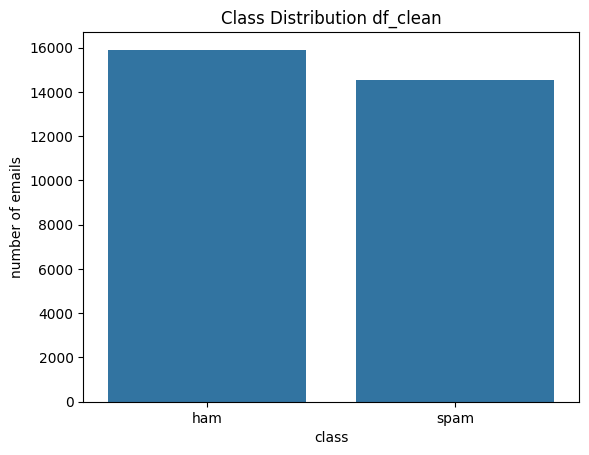

In [475]:
sns.countplot(data=df_clean, x="Spam/Ham")
plt.title("Class Distribution df_clean")
plt.xlabel("class")
plt.ylabel("number of emails")
plt.show()

In [476]:
df_clean["char_count"] = df_clean["text"].str.len()
df_clean["word_count"] = df_clean["text"].str.split().str.len()

length_summary = df_clean.groupby("Spam/Ham")[["char_count", "word_count"]].agg(["mean", "median"])
print("Text length summary by class:")
print(length_summary)

Text length summary by class:
           char_count         word_count       
                 mean median        mean median
Spam/Ham                                       
ham       1625.393652  790.0  346.356757  174.0
spam      1316.062534  650.0  261.799959  137.0


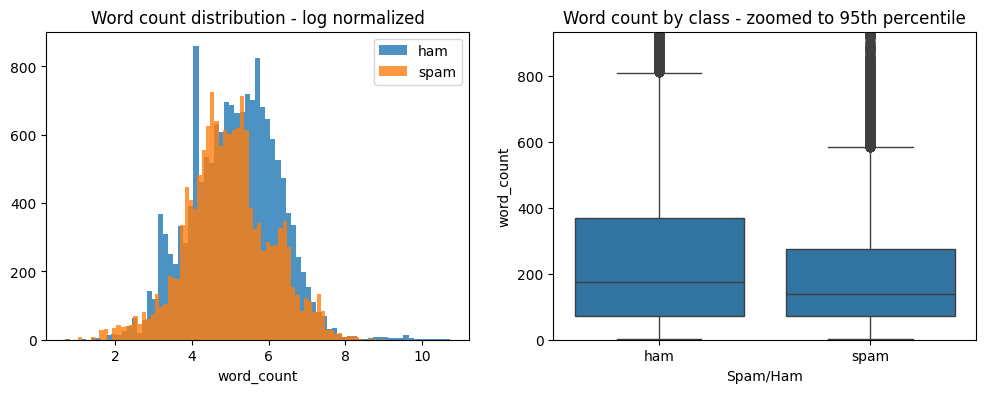

In [477]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for lab in ["ham", "spam"]:
    sub = np.log1p(df_clean.loc[df_clean["Spam/Ham"] == lab, "word_count"])
    axes[0].hist(sub, bins=75, alpha=.8, label=lab)
axes[0].set_title("Word count distribution - log normalized")
axes[0].set_xlabel("word_count")
axes[0].legend()

sns.boxplot(data=df_clean, x="Spam/Ham", y="word_count", ax=axes[1])
axes[1].set_ylim(0, df_clean["word_count"].quantile(0.95))
axes[1].set_title("Word count by class - zoomed to 95th percentile")

plt.show()

# Interpretation 
The dataset appears to be balanced, spam messages trend slightly shorter in text length. The average spam message is ~261 words and the average ham message is ~346 words. The ham messages appear to have more outliers as well, looking at the boxplot ham messages have a larger spread. 


## Part 4: Leakage and Dataset Caveat Analysis

Check whether non-content fields could accidentally reveal the label *before* training.

Email counts by year and class:
Spam/Ham   ham  spam
year                
1999       136     0
2000      6527     0
2001      7979    30
2002      1268   944
2003         0   103
2004         0  5505
2005         0  7970


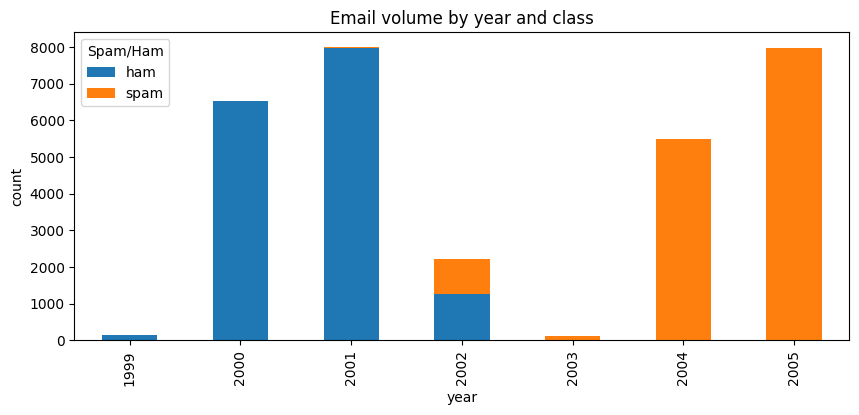

Share of spam/ham each year:
Spam/Ham       ham      spam
year                        
1999      1.000000  0.000000
2000      1.000000  0.000000
2001      0.996254  0.003746
2002      0.573237  0.426763
2003      0.000000  1.000000
2004      0.000000  1.000000
2005      0.000000  1.000000


In [478]:
df_clean["Date"] = pd.to_datetime(df_clean["Date"])
df_clean["year"] = df_clean["Date"].dt.year

class_by_year = pd.crosstab(df_clean["year"], df_clean["Spam/Ham"])
print("Email counts by year and class:")
print(class_by_year)

ax = class_by_year.plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Email volume by year and class")
plt.ylabel("count")
plt.show()

year_share = class_by_year.div(class_by_year.sum(axis=1), axis=0)
print("Share of spam/ham each year:")
print(year_share)

In [479]:
excluded_columns = ["Message ID", "Date"]
print("Columns EXCLUDED from modeling:", excluded_columns)
print("Model input feature:", "text (Subject + Message)")
print("Target:", "Spam/Ham  (spam = positive class = 1)")

Columns EXCLUDED from modeling: ['Message ID', 'Date']
Model input feature: text (Subject + Message)
Target: Spam/Ham  (spam = positive class = 1)


# Interpretation 

The above graph shows pretty definitively that the data can be easily separated by year in order to identify if the message was ham/spam, this is too obvious of a pattern so we must remove it from the model to prevent the model learning the date instead of the content of the email in order to determine spam/ham. MessageID is a unique identifier that does not really pertain to any of the data in the dataset anyways so this should also be removed to prevent the model from memorizing unique ids. 

Excluded columns: Message ID and Date
This model is learning how to detect ham vs spam and not necessarily phishing vs safe emails. 

## Part 5: Train-Test Split and TF-IDF Preparation

Prepare training and testing data. TF-IDF must be fit on the training text only.

In [480]:
X = df_clean["text"]
y = (df_clean["Spam/Ham"] == "spam").astype(int) 

X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.25,
    stratify=y,
    random_state=40103,
)
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print()
print("Training class proportions:")
print(y_train.value_counts(normalize=True))
print("Testing class proportions:")
print(y_test.value_counts(normalize=True))

Training rows: 22846
Testing rows: 7616

Training class proportions:
Spam/Ham
0    0.52228
1    0.47772
Name: proportion, dtype: float64
Testing class proportions:
Spam/Ham
0    0.522321
1    0.477679
Name: proportion, dtype: float64


In [481]:
# Fit TF-IDF on TRAINING text only, then transform the test text with the same vocabulary.
tfidf_demo = TfidfVectorizer(stop_words="english")
X_train_tfidf = tfidf_demo.fit_transform(X_train)   
X_test_tfidf = tfidf_demo.transform(X_test)         

print("TF-IDF vocabulary size:", len(tfidf_demo.vocabulary_))
print("Train matrix shape:", X_train_tfidf.shape)
print("Test matrix shape: ", X_test_tfidf.shape)

TF-IDF vocabulary size: 134651
Train matrix shape: (22846, 134651)
Test matrix shape:  (7616, 134651)


# Interpretation 

- If you fit on the full set then the data from the test set will leak into the training set, skewing the training results.

## Part 6: Baseline Text Classification Models

NB - classfication report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3978
           1       0.99      0.98      0.98      3638

    accuracy                           0.99      7616
   macro avg       0.99      0.99      0.99      7616
weighted avg       0.99      0.99      0.99      7616



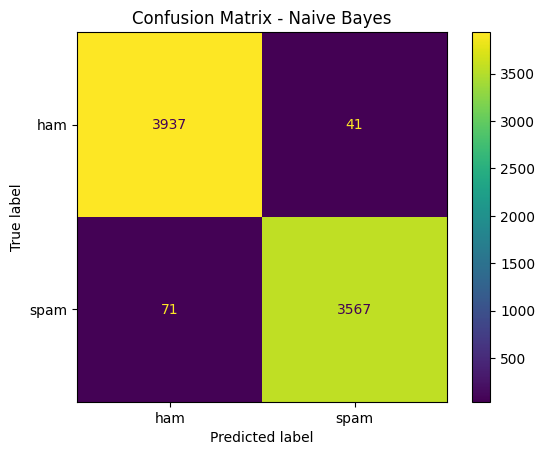

In [482]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", MultinomialNB()),
])
nb_pipeline.fit(X_train, y_train)
nb_pred = nb_pipeline.predict(X_test)

print("NB - classfication report")
print(classification_report(y_test, nb_pred, zero_division=0))

cm = confusion_matrix(y_test, nb_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

Linear SVM - classification report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      3978
           1       0.99      1.00      0.99      3638

    accuracy                           0.99      7616
   macro avg       0.99      0.99      0.99      7616
weighted avg       0.99      0.99      0.99      7616



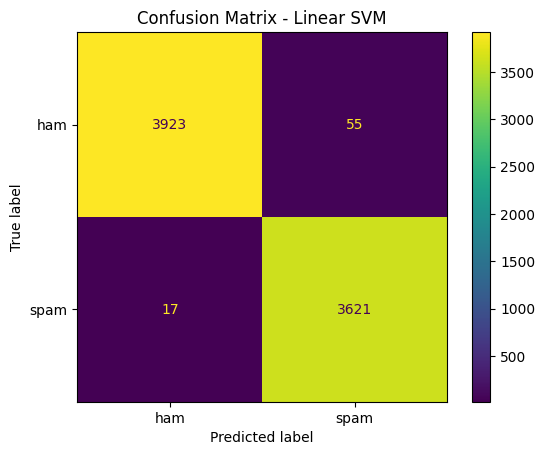

In [483]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("clf", LinearSVC()),
])
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)

print("Linear SVM - classification report:")
print(classification_report(y_test, svm_pred, zero_division=0))

cm = confusion_matrix(y_test, svm_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(values_format="d")
plt.title("Confusion Matrix - Linear SVM")
plt.show()

In [484]:
def spam_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),   
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

baseline_summary = pd.DataFrame({
    "Naive Bayes": spam_metrics(y_test, nb_pred),
    "Linear SVM": spam_metrics(y_test, svm_pred),
}).T
print("Baseline test-set metrics:")
baseline_summary

Baseline test-set metrics:


,Accuracy,Precision,Recall,F1
Naive Bayes,0.985294,0.988636,0.980484,0.984543
Linear SVM,0.990546,0.985038,0.995327,0.990156


## Part 7: Stratified k-Fold Cross-Validation

In [485]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=40103)
scoring = ["accuracy", "precision", "recall", "f1"]

cv_pipelines = {
    "Naive Bayes": Pipeline([("tfidf", TfidfVectorizer(stop_words="english")), ("clf", MultinomialNB())]),
    "Linear SVM": Pipeline([("tfidf", TfidfVectorizer(stop_words="english")), ("clf", LinearSVC())]),
}

cv_rows = []
for name, pipe in cv_pipelines.items():
    s = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    cv_rows.append({
        "Model": name,
        "CV Accuracy": s["test_accuracy"].mean(),
        "CV Precision": s["test_precision"].mean(),
        "CV Recall": s["test_recall"].mean(),
        "CV F1": s["test_f1"].mean(),
    })

cv_summary = pd.DataFrame(cv_rows).set_index("Model")
print("Stratified 5-fold cross-validation (means across folds")
cv_summary

Stratified 5-fold cross-validation (means across folds


,CV Accuracy,CV Precision,CV Recall,CV F1
Model,,,,
Naive Bayes,0.986803,0.99064,0.981652,0.986123
Linear SVM,0.990414,0.98530,0.994777,0.990015


# Interpretation

- The metrics reported from the cross-validation was extremely similar to the test results from part 6, indicating that the training results from part 6 are representative of the models performance. 
- stratified cross-validation is useful for text-based security datasets because it keeps results stable by preserving the ratio of the data used across the splits and then averaging out the results. 

## Part 8: SVM Variant Sample Experiment

In [486]:
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=5000, stratify=y, random_state=40103
)
print("Sample size:", len(X_sample))
print("Sample class distribution:")
print(y_sample.value_counts())

Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(
    X_sample, y_sample, test_size=0.25, stratify=y_sample, random_state=40103
)

Sample size: 5000
Sample class distribution:
Spam/Ham
0    2611
1    2389
Name: count, dtype: int64


In [487]:
svm_variants = {
    "Linear SVM": LinearSVC(),
    "RBF SVM": SVC(kernel="rbf", C=1, gamma="scale"),
    "Polynomial SVM": SVC(kernel="poly", degree=2, C=1, gamma="scale"),
    "Sigmoid SVM": SVC(kernel="sigmoid", C=1, gamma="scale"),
}

svm_rows = []
for name, clf in svm_variants.items():
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(stop_words="english")), 
        ("clf", clf),
    ])
    pipe.fit(Xs_tr, ys_tr)
    p = pipe.predict(Xs_te)
    svm_rows.append({"SVM Variant": name, "Sample Size": len(X_sample), **spam_metrics(ys_te, p)})

svm_sample_results = pd.DataFrame(svm_rows).set_index("SVM Variant")
svm_sample_results

,Sample Size,Accuracy,Precision,Recall,F1
SVM Variant,,,,,
Linear SVM,5000,0.9824,0.970540,0.993300,0.981788
RBF SVM,5000,0.9760,0.959481,0.991625,0.975288
Polynomial SVM,5000,0.9752,0.959416,0.989950,0.974444
Sigmoid SVM,5000,0.9800,0.967320,0.991625,0.979322


# Interpretation

- The Linear SVM still performed the best across all of the models and had an even better score, when it was ran during the cross-validation, so the extra computational cost of the other models did not translate to a better performance. 

## Part 9: MLPClassifier Experiment

Train one Multi-Layer Perceptron on a limited TF-IDF feature space so it runs in reasonable time.

MLP settings:
 hidden_layer_sizes=(128,)
 activation='relu'
 max_iter=30, 
random_state=40103, 
 early_stopping=True, 
TF-IDF max_features=5000

MLPClassifier - Classification Report (spam = positive):
              precision    recall  f1-score   support

     ham (0)       0.99      0.99      0.99      3978
    spam (1)       0.98      0.99      0.99      3638

    accuracy                           0.99      7616
   macro avg       0.99      0.99      0.99      7616
weighted avg       0.99      0.99      0.99      7616



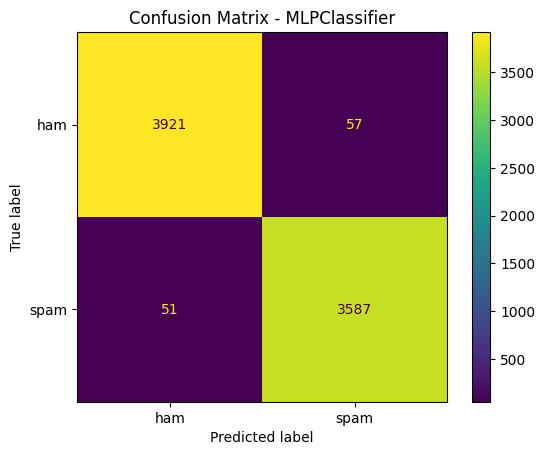

In [488]:
mlp_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_features=5000)),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128,),
        activation="relu",
        max_iter=30,
        random_state=40103,
        early_stopping=True,
    )),
])
mlp_pipeline.fit(X_train, y_train)
mlp_pred = mlp_pipeline.predict(X_test)

print("MLP settings:\n hidden_layer_sizes=(128,)\n activation='relu'\n max_iter=30, \n"
      "random_state=40103, \n early_stopping=True, \nTF-IDF max_features=5000")
print()
print("MLPClassifier - Classification Report (spam = positive):")
print(classification_report(y_test, mlp_pred, target_names=["ham (0)", "spam (1)"]))

cm = confusion_matrix(y_test, mlp_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"]).plot(values_format="d")
plt.title("Confusion Matrix - MLPClassifier")
plt.show()

In [489]:
mlp_compare = pd.DataFrame({
    "Naive Bayes": spam_metrics(y_test, nb_pred),
    "Linear SVM": spam_metrics(y_test, svm_pred),
    "MLPClassifier": spam_metrics(y_test, mlp_pred),
}).T
print("MLP vs baselines (test set, spam = positive):")
mlp_compare

MLP vs baselines (test set, spam = positive):


,Accuracy,Precision,Recall,F1
Naive Bayes,0.985294,0.988636,0.980484,0.984543
Linear SVM,0.990546,0.985038,0.995327,0.990156
MLPClassifier,0.985819,0.984358,0.985981,0.985169


# Interpretation 

- Due to MLP's extra compute the feature size was limited in order to make training more practical for a quick comparison. The result from the MLPClassifier does about as good as Naive Bayes model, but still slightly worse than the Linear SVM model. So the extra compute for the multi-layer perceptron is not worth it in this case. 

## Part 10: BERT Component  

In [490]:
spam_s = df_clean[df_clean["Spam/Ham"] == "spam"].sample(n=1000, random_state=40103)
ham_s = df_clean[df_clean["Spam/Ham"] == "ham"].sample(n=1000, random_state=40103)
bert_sample = pd.concat([spam_s, ham_s]).sample(frac=1, random_state=40103)

X_bert = bert_sample["text"].tolist()
y_bert = (bert_sample["Spam/Ham"] == "spam").astype(int).values

Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
    X_bert, y_bert, test_size=0.25, stratify=y_bert, random_state=40103
)
print("BERT sample size:", len(X_bert))
print("Sample class distribution:")
print(bert_sample["Spam/Ham"].value_counts())
print("Train emails:", len(Xb_tr), " Test emails:", len(Xb_te))

BERT sample size: 2000
Sample class distribution:
Spam/Ham
spam    1000
ham     1000
Name: count, dtype: int64
Train emails: 1500  Test emails: 500


In [491]:
if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

bert_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(bert_name)
print("Loaded", bert_name, "on device:", device)

demo = Xb_tr[0]
print("\nExample email (first 100 chars):", demo[:150])
print("Tokens:", tokenizer.tokenize(demo)[:25], "...")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (519 > 512). Running this sequence through the model will result in indexing errors


Loaded bert-base-uncased on device: mps

Example email (first 100 chars): economy is finally getting better hi , i am just doing a follow - up email concerning the
conversation you had last week with jesus regarding your mor
Tokens: ['economy', 'is', 'finally', 'getting', 'better', 'hi', ',', 'i', 'am', 'just', 'doing', 'a', 'follow', '-', 'up', 'email', 'concerning', 'the', 'conversation', 'you', 'had', 'last', 'week', 'with', 'jesus'] ...


In [492]:
import time

def embed_texts(texts, batch_size=32, max_length=128):
    """Mean-pool BERT's last hidden states into one 768-dim vector per email."""
    vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            batch, padding=True, truncation=True,
            max_length=max_length, return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            out = bert_model(**enc)
        last_hidden = out.last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1)
        summed = (last_hidden * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)
        mean_pooled = summed / counts
        vecs.append(mean_pooled.cpu().numpy())
    return np.vstack(vecs)

t0 = time.time()
Xb_tr_emb = embed_texts(Xb_tr)
Xb_te_emb = embed_texts(Xb_te)
print("Train embeddings:", Xb_tr_emb.shape, " Test embeddings:", Xb_te_emb.shape)
print(f"Embedding time: {time.time() - t0:.1f}s")

Train embeddings: (1500, 768)  Test embeddings: (500, 768)
Embedding time: 16.8s


BERT embeddings + LinearSVC - Classification Report
              precision    recall  f1-score   support

     ham (0)       0.95      0.96      0.96       250
    spam (1)       0.96      0.95      0.96       250

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



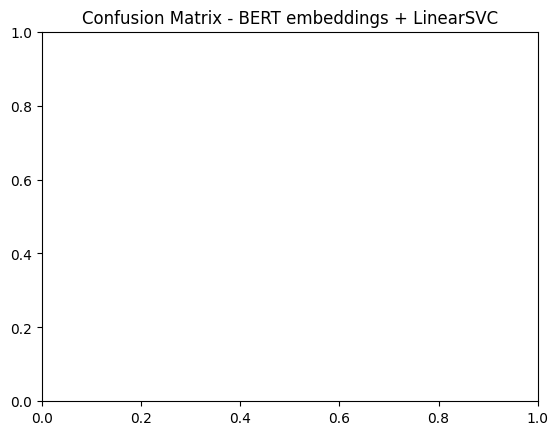

BERT metrics: {'Accuracy': 0.958, 'Precision': 0.9635627530364372, 'Recall': 0.952, 'F1': 0.9577464788732394}


In [493]:
from sklearn.preprocessing import StandardScaler

bert_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearSVC(max_iter=5000)),
])
bert_clf.fit(Xb_tr_emb, yb_tr)
bert_pred = bert_clf.predict(Xb_te_emb)

print("BERT embeddings + LinearSVC - Classification Report")
print(classification_report(yb_te, bert_pred, target_names=["ham (0)", "spam (1)"]))

cm = confusion_matrix(yb_te, bert_pred)
ConfusionMatrixDisplay(cm, display_labels=["ham", "spam"])
plt.title("Confusion Matrix - BERT embeddings + LinearSVC")
plt.show()

bert_metrics = spam_metrics(yb_te, bert_pred)   # reuse helper from Part 6
print("BERT metrics:", {key: value for key, value in bert_metrics.items()})

# Interpretation 

- The bert model is the bert-base-uncased
- sample size was 2000 emails, split in half between ham and spam

## Part 11: Final Model Comparison


In [494]:
def test_metrics(model):
    return spam_metrics(y_test, model.predict(X_test))

best_variant = svm_sample_results["F1"].idxmax()

bert_row = bert_metrics if "bert_metrics" in globals() else {
    "Accuracy": np.nan, "Precision": np.nan, "Recall": np.nan, "F1": np.nan, "Main Strength": np.nan, "Main Weakness": np.nan
}

final_rows = [
    {"Model": "Naive Bayes", "Data Used": "Full dataset", **test_metrics(nb_pipeline),"Main Strength": "Precision", "Main Weakness": "Recall"},
    {"Model": "Linear SVM", "Data Used": "Full dataset", **test_metrics(svm_pipeline), "Main Strength": "Recall", "Main Weakness": "Precision"},
    {"Model": f"Best SVM Variant ({best_variant})", "Data Used": "Sample (n=5000)",
     **svm_sample_results.loc[best_variant, ["Accuracy", "Precision", "Recall", "F1"]].to_dict(), "Main Strength": "Recall", "Main Weakness": "Precision"},
    {"Model": "MLPClassifier", "Data Used": "Full data, limited features", **test_metrics(mlp_pipeline), "Main Strength": "Recall", "Main Weakness": "Precision"},
    {"Model": "BERT (embeddings + SVM)", "Data Used": "Sample (n=2000)", **bert_row, "Main Strength": "Precision", "Main Weakness": "Recall"},
]
final_comparison = pd.DataFrame(final_rows).set_index("Model")
print("Final model comparison (spam = positive class).")
final_comparison.round(4)

Final model comparison (spam = positive class).


,Data Used,Accuracy,Precision,Recall,F1,Main Strength,Main Weakness
Model,,,,,,,
Naive Bayes,Full dataset,0.9853,0.9886,0.9805,0.9845,Precision,Recall
Linear SVM,Full dataset,0.9905,0.9850,0.9953,0.9902,Recall,Precision
Best SVM Variant (Linear SVM),Sample (n=5000),0.9824,0.9705,0.9933,0.9818,Recall,Precision
MLPClassifier,"Full data, limited features",0.9858,0.9844,0.9860,0.9852,Recall,Precision
BERT (embeddings + SVM),Sample (n=2000),0.9580,0.9636,0.9520,0.9577,Precision,Recall


In [ ]:
import re

def sanitize(text, max_len=160):
    """Mask PII and shorten an email to a safe excerpt for display."""
    text = re.sub(r"[\w.+-]+@[\w-]+\.[\w.-]+", "[EMAIL]", str(text).strip())
    text = re.sub(r"\+?\d[\d\-.\s()]{6,}\d", "[PHONE]", text)
    text = re.sub(r"\d{5,}", "[NUM]", text)
    text = re.sub(r"\s+", " ", text).strip()           
    return text[:max_len] + ("..." if len(text) > max_len else "")

err_df = pd.DataFrame({"text": X_test, "true": y_test, "pred": svm_pipeline.predict(X_test)})
false_positives = err_df[(err_df["true"] == 0) & (err_df["pred"] == 1)]  
false_negatives = err_df[(err_df["true"] == 1) & (err_df["pred"] == 0)]  

print(f"Linear SVM  |  false positives: {len(false_positives)}  |  false negatives: {len(false_negatives)}")

print()
print("FALSE POSITIVES")
fp = false_positives[~false_positives["text"].str.contains("@")]
for text in fp["text"].head(5):
    print(" -", sanitize(text))

print()
print("FALSE NEGATIVES")
fn = false_negatives[~false_negatives["text"].str.contains("@")]
for text in fn["text"].head(5):
    print(" -", sanitize(text))

Linear SVM  |  false positives: 55  |  false negatives: 17

FALSE POSITIVES
 - final final version i have added shell and deleted south hampton .
 - anadarko and union pacific resources merged company will be named anadarko petroleum shareholders of anadarko petroleum and union pacific resources voted to app...
 - the dot is coming that ' s right ; the dot is coming . prepare to be enlightened , entertained and engaged . prepare to receive information online that is so cu...
 - it ' s not the same without your smiling face ! ! ! ! ! ! i hope all is well for you and your family . . . . how is that precious daughter of yours ? i bet megh...
 - marketers we are dropping a lot of marketers . it would be nice to keep 1 or 2 .

FALSE NEGATIVES
 - neuro tests end december 15 th
 - referred by , james hi , i found following web site quite interesting . i am sure it will ease your access to middle eastern markets . http : / / www . ceobusin...
 - powerball results saturday september 14 , 2002 e

# Interpretation

- Based on the f1 score the best overall model is the Linear SVM model
- Linear SVM also had the best recall score of all the models. 
- Since we are really just filtering out spam vs ham and not real phishing emails I would say having more false negatives is probably better than having a lot of false positives. I think most people would prefer to audit more messages, than lose messages and have to dig through their spam/trash for them. 

## Part 12: Deployment Recommendation

# Interpretation

Base this on your actual metrics and confusion matrices above:
- I would deploy the linear svm model since it had the best f1 score, the naive bayes had a slightly higher precision which is tempting, but not so much that I would choose it over svm. 
- I think it should send any flagged emails to the user and then just add a warning label
- A high spam recall might mean that no spam gets through, but if that is at the cost of losing valuable normal messages then it is probably not worth it. 

## Part 13: AI Use Statement

- I used claude code to help me frame out a lot of the code blocks for the naive bayes and linear svm models. I also used claude to help me understand BERT better and decided what was the best way to implement. I used google to get a better understanding of concepts like the model and would write out what my thoughts were and then would ask claude to review what I had written. 